# Image generation from brain activity
## Metrics

Работа в блокноте проводилась на kaggle

In [1]:
!pip install clip-retrieval clip ftfy regex kornia > None
!pip install torchmetrics[image] > None
!pip install torch-fidelity > None

In [2]:
import os
from tqdm import tqdm
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd

from collections import OrderedDict

from PIL import Image 
import torch
from torchvision.utils import make_grid
import torchvision.transforms as transforms
from torchvision.utils import make_grid
from torch.utils.data import Dataset
from torch import nn, optim
from torchmetrics.image.fid import FrechetInceptionDistance

from ignite.engine import *
from ignite.handlers import *
from ignite.metrics import *
from ignite.metrics.regression import *
from ignite.utils import *


img_size = 448
seed=42

pil_transform = transforms.Compose([transforms.PILToTensor()])
gen_transform = transforms.Compose([transforms.Resize(size=(img_size, img_size))])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# create default evaluator for doctests
def eval_step(engine, batch):
    return batch

# create default trainer for doctests
# as handlers could be attached to the trainer,
# each test must define his own trainer using `.. testsetup:`
def get_default_trainer():

    def train_step(engine, batch):
        return batch

    return Engine(train_step)



default_evaluator = Engine(eval_step)

# create default optimizer for doctests
param_tensor = torch.zeros([1], requires_grad=True)
default_optimizer = torch.optim.SGD([param_tensor], lr=0.1)

# create default model for doctests
default_model = nn.Sequential(OrderedDict([
    ('base', nn.Linear(4, 2)),
    ('fc', nn.Linear(2, 1))
]))

manual_seed(666)

### Загрузка данных

In [4]:
count = 491

test_paths = sorted([os.path.join('/kaggle/input/inference-testing/test', name) 
                     for name in os.listdir('/kaggle/input/inference-testing/test') 
                     if int(name.split('.')[0]) in range(count)])
test_gen_paths = sorted([os.path.join('/kaggle/input/inference-testing/test_gen', name) 
                         for name in os.listdir('/kaggle/input/inference-testing/test_gen') 
                         if int(name.split('.')[0]) in range(count)])

In [5]:
all_images = torch.zeros((count, 3, img_size, img_size))
all_brain_recons = torch.zeros((count, 3, img_size, img_size))

for index, (test_path, test_gen_path) in enumerate(zip(test_paths, test_gen_paths)):
    orig_im = Image.open(test_gen_path)
    orig_tensor = pil_transform(orig_im) / 256
    
    gen_tensor = torch.Tensor(np.load(test_path)).permute(2, 0, 1)
    gen_tensor = gen_transform(gen_tensor) / 256
    
    all_images[index] = orig_tensor
    all_brain_recons[index] = gen_tensor

/opt/conda/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


In [6]:
print(all_images.shape)
print(all_brain_recons.shape)

all_images = all_images.to(device)
all_brain_recons = all_brain_recons.to(device).to(all_images.dtype).clamp(0,1)

torch.Size([491, 3, 448, 448])
torch.Size([491, 3, 448, 448])


### Визуализация данных

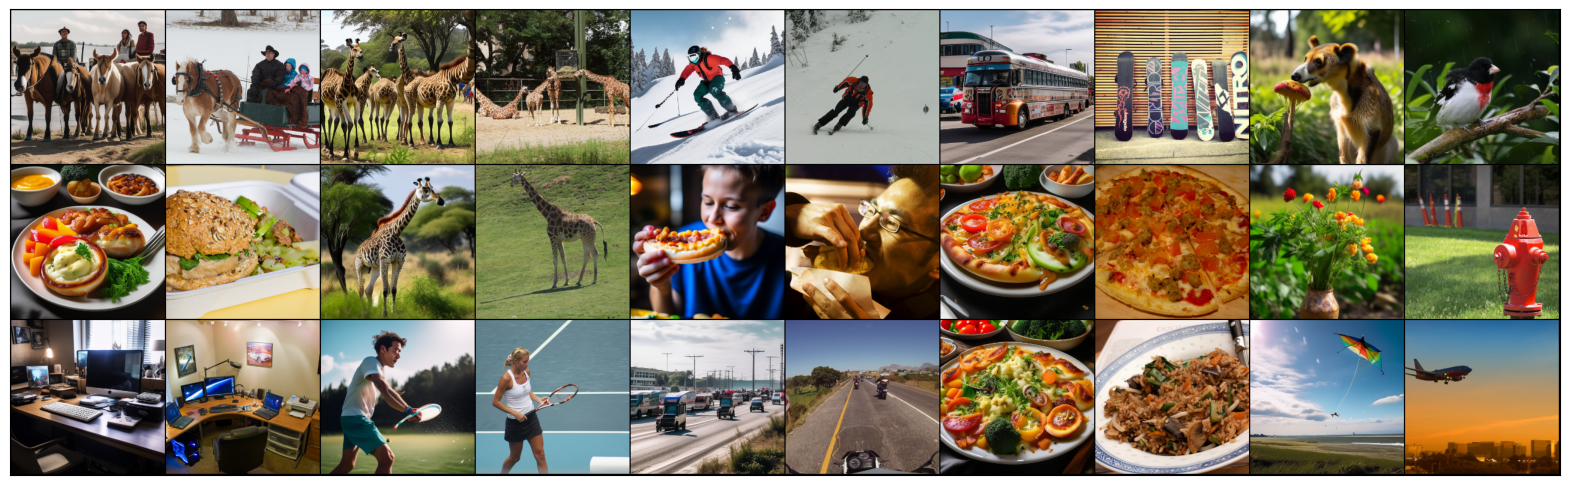

In [7]:
imsize = 256
all_images = transforms.Resize((imsize,imsize))(all_images)
all_brain_recons = transforms.Resize((imsize,imsize))(all_brain_recons)

np.random.seed(0)
ind = np.flip(np.array([112,119,101,44,159,22,173,174,175,189,243,249,255,265, 100]))

all_interleaved = torch.zeros(len(ind)*2,3,imsize,imsize)
icount = 0
for t in ind:
    all_interleaved[icount] = all_images[t]
    all_interleaved[icount+1] = all_brain_recons[t]
    icount += 2

plt.rcParams["savefig.bbox"] = 'tight'
def show(imgs,figsize):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False, figsize=figsize)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = transforms.ToPILImage()(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
    
grid = make_grid(all_interleaved, nrow=10, padding=2)
show(grid,figsize=(20,16))

### 2-Way Identification

In [8]:
from torchvision.models.feature_extraction import create_feature_extractor, get_graph_node_names

@torch.no_grad()
def two_way_identification(all_brain_recons, all_images, model, preprocess, feature_layer=None, return_avg=True):
    preds = model(torch.stack([preprocess(recon) for recon in all_brain_recons], dim=0).to(device))
    reals = model(torch.stack([preprocess(indiv) for indiv in all_images], dim=0).to(device))
    if feature_layer is None:
        preds = preds.float().flatten(1).cpu().numpy()
        reals = reals.float().flatten(1).cpu().numpy()
    else:
        preds = preds[feature_layer].float().flatten(1).cpu().numpy()
        reals = reals[feature_layer].float().flatten(1).cpu().numpy()

    r = np.corrcoef(reals, preds)
    r = r[:len(all_images), len(all_images):]
    congruents = np.diag(r)

    success = r < congruents
    success_cnt = np.sum(success, 0)

    if return_avg:
        perf = np.mean(success_cnt) / (len(all_images)-1)
        return perf
    else:
        return success_cnt, len(all_images)-1

### PixCorr 

In [9]:
preprocess = transforms.Compose([
    transforms.Resize(425, interpolation=transforms.InterpolationMode.BILINEAR),
])

# Flatten images while keeping the batch dimension
all_images_flattened = preprocess(all_images).reshape(len(all_images), -1).cpu()
all_brain_recons_flattened = preprocess(all_brain_recons).view(len(all_brain_recons), -1).cpu()

print(all_images_flattened.shape)
print(all_brain_recons_flattened.shape)

corrsum = 0
for i in tqdm(range(count)):
    corrsum += np.corrcoef(all_images_flattened[i], all_brain_recons_flattened[i])[0][1]
corrmean = corrsum / count

pixcorr = corrmean
print(pixcorr)

torch.Size([491, 541875])
torch.Size([491, 541875])


100%|██████████| 491/491 [00:02<00:00, 240.65it/s]

0.11482011505977487


### SSIM 

In [10]:
# see https://github.com/zijin-gu/meshconv-decoding/issues/3
from skimage.color import rgb2gray
from skimage.metrics import structural_similarity as ssim

preprocess = transforms.Compose([
    transforms.Resize(425, interpolation=transforms.InterpolationMode.BILINEAR), 
])

# convert image to grayscale with rgb2grey
img_gray = rgb2gray(preprocess(all_images).permute((0,2,3,1)).cpu())
recon_gray = rgb2gray(preprocess(all_brain_recons).permute((0,2,3,1)).cpu())
print("converted, now calculating ssim...")

ssim_score=[]
for im,rec in tqdm(zip(img_gray,recon_gray),total=len(all_images)):
    ssim_score.append(ssim(rec, im, multichannel=True, gaussian_weights=True, sigma=1.5, use_sample_covariance=False, data_range=1.0))

ssim = np.mean(ssim_score)
print(ssim)

/opt/conda/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


converted, now calculating ssim...


100%|██████████| 491/491 [00:07<00:00, 68.08it/s]

0.2681191383401323


### AlexNet

In [11]:
from torchvision.models import alexnet, AlexNet_Weights
alex_weights = AlexNet_Weights.IMAGENET1K_V1

alex_model = create_feature_extractor(alexnet(weights=alex_weights), return_nodes=['features.4','features.11']).to(device)
alex_model.eval().requires_grad_(False)

# see alex_weights.transforms()
preprocess = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

layer = 'early, AlexNet(2)'
print(f"\n---{layer}---")
all_per_correct = two_way_identification(all_brain_recons.to(device).float(), all_images, 
                                                          alex_model, preprocess, 'features.4')
alexnet2 = np.mean(all_per_correct)
print(f"2-way Percent Correct: {alexnet2:.4f}")

layer = 'mid, AlexNet(5)'
print(f"\n---{layer}---")
all_per_correct = two_way_identification(all_brain_recons.to(device).float(), all_images, 
                                                          alex_model, preprocess, 'features.11')
alexnet5 = np.mean(all_per_correct)
print(f"2-way Percent Correct: {alexnet5:.4f}")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:01<00:00, 168MB/s]  
/opt/conda/lib/python3.10/site-packages/torch/overrides.py:110: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  torch.has_cuda,
/opt/conda/lib/python3.10/site-packages/torch/overrides.py:111: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  torch.has_cudnn,
/opt/conda/lib/python3.10/site-packages/torch/overrides.py:117: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  torch.has_mps,
/opt/conda/lib/python3.10/site-packages/torch/overrides.py:118: UserWarning: 'has_mkldnn' is deprecated, please use 'torch.backends.mkldnn.is_available()'
  torch.has_mkldnn,



---early, AlexNet(2)---
2-way Percent Correct: 0.7922

---mid, AlexNet(5)---
2-way Percent Correct: 0.8981


### InceptionV3

In [12]:
from torchvision.models import inception_v3, Inception_V3_Weights
weights = Inception_V3_Weights.DEFAULT
inception_model = create_feature_extractor(inception_v3(weights=weights), 
                                           return_nodes=['avgpool']).to(device)
inception_model.eval().requires_grad_(False)

# see weights.transforms()
preprocess = transforms.Compose([
    transforms.Resize(342, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

all_per_correct = two_way_identification(all_brain_recons, all_images,
                                        inception_model, preprocess, 'avgpool')
        
inception = np.mean(all_per_correct)
print(f"2-way Percent Correct: {inception:.4f}")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 169MB/s]  
/opt/conda/lib/python3.10/site-packages/torchvision/models/feature_extraction.py:174: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


2-way Percent Correct: 0.8945


### CLIP

In [13]:
import clip
clip_model, preprocess = clip.load("ViT-L/14", device=device)

preprocess = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])

all_per_correct = two_way_identification(all_brain_recons, all_images,
                                        clip_model.encode_image, preprocess, None) # final layer
clip_ = np.mean(all_per_correct)
print(f"2-way Percent Correct: {clip_:.4f}")

100%|████████████████████████████████████████| 933M/933M [00:07<00:00, 129MiB/s]


2-way Percent Correct: 0.8905


### Efficient Net

In [14]:
from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights
weights = EfficientNet_B1_Weights.DEFAULT
eff_model = create_feature_extractor(efficientnet_b1(weights=weights), 
                                    return_nodes=['avgpool']).to(device)
eff_model.eval().requires_grad_(False)

# see weights.transforms()
preprocess = transforms.Compose([
    transforms.Resize(255, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

gt = eff_model(preprocess(all_images))['avgpool']
gt = gt.reshape(len(gt),-1).cpu().numpy()
fake = eff_model(preprocess(all_brain_recons))['avgpool']
fake = fake.reshape(len(fake),-1).cpu().numpy()

effnet = np.array([sp.spatial.distance.correlation(gt[i],fake[i]) for i in range(len(gt))]).mean()
print("Distance:",effnet)

Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1-c27df63c.pth
100%|██████████| 30.1M/30.1M [00:00<00:00, 125MB/s] 


Distance: 0.7262447034181883


### SwAV

In [15]:
swav_model = torch.hub.load('facebookresearch/swav:main', 'resnet50')
swav_model = create_feature_extractor(swav_model, 
                                    return_nodes=['avgpool']).to(device)
swav_model.eval().requires_grad_(False)

preprocess = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

gt = swav_model(preprocess(all_images))['avgpool']
gt = gt.reshape(len(gt),-1).cpu().numpy()
fake = swav_model(preprocess(all_brain_recons))['avgpool']
fake = fake.reshape(len(fake),-1).cpu().numpy()

swav = np.array([sp.spatial.distance.correlation(gt[i],fake[i]) for i in range(len(gt))]).mean()
print("Distance:",swav)

Downloading: "https://github.com/facebookresearch/swav/zipball/main" to /root/.cache/torch/hub/main.zip
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Downloading: "https://dl.fbaipublicfiles.com/deepcluster/swav_800ep_pretrain.pth.tar" to /root/.cache/torch/hub/checkpoints/swav_800ep_pretrain.pth.tar
100%|██████████| 108M/108M [00:00<00:00, 201MB/s]  


Distance: 0.449710038887022


### Inception Score

In [16]:
metric = InceptionScore()
metric.attach(default_evaluator, "is")
state = default_evaluator.run([all_brain_recons])

In [17]:
iscore = state.metrics["is"]
print(iscore)

68.61154212939256


### FID

In [18]:
metric = FrechetInceptionDistance(feature=64)
metric.update((all_images * 256).type(torch.uint8).to('cpu'), real=True)
metric.update((all_brain_recons * 256).type(torch.uint8).to('cpu'), real=False)

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 271MB/s]


In [19]:
fid = metric.compute().item()
print(fid)

1.118643879890442


### Display in Table

In [20]:
# Create a dictionary to store variable names and their corresponding values
data = {
    "Metric": ["PixCorr", "SSIM", "AlexNet(2)", "AlexNet(5)", "InceptionV3", "CLIP", "EffNet-B", "SwAV", "IS", "FID"],
    "Value": [pixcorr, ssim, alexnet2, alexnet5, inception, clip_, effnet, swav, iscore, fid],
}

df = pd.DataFrame(data)
print(df.to_string(index=False))

# # save table to txt file
# df.to_csv(f'{recon_path[:-3]}.csv', sep='\t', index=False)

     Metric     Value
    PixCorr  0.114820
       SSIM  0.268119
 AlexNet(2)  0.792203
 AlexNet(5)  0.898055
InceptionV3  0.894543
       CLIP  0.890490
   EffNet-B  0.726245
       SwAV  0.449710
         IS 68.611542
        FID  1.118644
